### Import Library

Pada bagian ini, kita mengimpor berbagai library Python yang dibutuhkan untuk membangun, melatih, dan mengevaluasi model **ensemble TCN–BiLSTM**.

#### 1. Library Sistem & Utilitas
- **`os`** → manajemen path dan file sistem.
- **`numpy`** → operasi numerik berbasis array.
- **`pandas`** → manipulasi data tabular (DataFrame).

#### 2. TensorFlow & Keras
- **`tensorflow as tf`** → framework deep learning utama.
- **`keras`** → API high-level untuk membangun model.
- **`layers, regularizers`** → membangun layer neural network (Dense, LSTM, TCN, dsb.) dan menambahkan regularisasi (L1/L2).
- **`keras.utils.Sequence`** → membuat generator data kustom yang efisien untuk training batch besar.

#### 3. Scikit-learn (Preprocessing & Evaluasi)
- **`StandardScaler`** → normalisasi fitur numerik.
- **`LabelEncoder`** → encoding label kategori menjadi angka.
- **`classification_report, confusion_matrix, ConfusionMatrixDisplay`** → evaluasi performa model klasifikasi.
- **`f1_score, log_loss`** → metrik tambahan untuk menilai kualitas prediksi.
- **`train_test_split`** → membagi dataset menjadi train dan test set.

#### 4. Visualisasi
- **`matplotlib.pyplot`** → membuat grafik (akurasi, loss, confusion matrix).

#### 5. Utilitas Tambahan
- **`collections.Counter`** → menghitung distribusi kelas.
- **`itertools.product`** → membuat kombinasi parameter (misalnya untuk grid search atau ensemble).

---

Dengan import ini, pipeline siap untuk:
- **Preprocessing data** (scaling, encoding).
- **Membangun model deep learning** (TCN + BiLSTM).
- **Evaluasi performa** dengan metrik klasifikasi.
- **Visualisasi hasil** untuk analisis.


In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.utils import Sequence
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, log_loss
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter
from itertools import product
import json

### Konfigurasi Awal & Hyperparameter

Pada bagian ini ditentukan path dataset, kolom penting, serta hyperparameter utama yang akan digunakan dalam pipeline TCN–BiLSTM.

#### 1. Path & Kolom Dataset
- **`CSV_PATH`** → lokasi file dataset cuaca (`dataset_cuaca_manokwari.csv`).
- **`TIME_COLUMN = "datetime"`** → kolom penanda waktu.
- **`TARGET_COLUMN = "cuaca"`** → kolom target yang akan diprediksi (label cuaca).

#### 2. Parameter Sequence & Training
- **`SEQ_LEN = 24`** → panjang urutan input (24 jam terakhir digunakan untuk memprediksi kondisi berikutnya).
- **`HORIZON = 1`** → horizon prediksi (1 langkah ke depan).
- **`BATCH_SIZE = 64`** → jumlah sampel per batch saat training.
- **`EPOCHS = 50`** → jumlah maksimum iterasi training.

#### 3. Reproducibility
- **`SEED = 42`** → seed random untuk memastikan hasil eksperimen konsisten.
- **`np.random.seed(SEED)`** dan **`tf.random.set_seed(SEED)`** → mengunci random state di NumPy dan TensorFlow.

#### 4. Pengaturan Loss & Class Balancing
- **`USE_FOCAL_LOSS = True`** → menggunakan *Focal Loss* untuk menangani ketidakseimbangan kelas.
- **`FOCAL_GAMMA = 2.0`** → parameter gamma pada Focal Loss (semakin besar → semakin fokus pada sampel sulit).
- **`MAX_CLASS_WEIGHT = 5.0`** → batas maksimum bobot kelas agar tidak terlalu ekstrem.
- **`BALANCE_RATIO = 0.6`** → rasio penyeimbang distribusi kelas dalam batch generator.

---

Dengan konfigurasi ini, pipeline siap untuk:
- Membaca dataset cuaca.
- Membentuk sequence input sepanjang 24 jam.
- Melatih model dengan batch 64, hingga 50 epoch.
- Menggunakan strategi balancing (Focal Loss + class weight) agar model tidak bias ke kelas mayoritas.


In [21]:
CSV_PATH = r"../Dataset/Suhu/Prakiraan/dataset_cuaca_manokwari.csv"
TIME_COLUMN = "datetime"
TARGET_COLUMN = "cuaca"
SEQ_LEN = 24
HORIZON = 1
BATCH_SIZE = 64
EPOCHS = 50
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

USE_FOCAL_LOSS = True
FOCAL_GAMMA = 2.0
MAX_CLASS_WEIGHT = 5.0
BALANCE_RATIO = 0.6

Bagian 3: Feature Engineering

Pada bagian ini dibuat fungsi-fungsi untuk memperkaya dataset cuaca dengan fitur tambahan.  
Tujuannya adalah agar model tidak hanya belajar dari nilai mentah, tetapi juga dari **pola waktu** dan **perubahan variabel cuaca**.

---

#### 1. Fungsi `find_first(df, keys)`
- Mencari kolom pertama dalam DataFrame yang:
  - Namanya mengandung salah satu kata kunci (`keys`).
  - Bertipe numerik.
- Contoh: jika `keys=["suhu","temp"]`, maka fungsi akan mencari kolom dengan nama mengandung "suhu" atau "temp".
- Berguna untuk dataset dengan variasi nama kolom antar sumber.

---

#### 2. Fungsi `add_time_features(df, time_col)`
- Mengubah kolom waktu (`time_col`) menjadi fitur tambahan:
  - **`hour`** → jam (0–23).
  - **`dayofweek`** → hari dalam minggu (0=Senin, 6=Minggu).
  - **`month`** → bulan (1–12).
- Menambahkan **encoding siklikal** agar model bisa menangkap pola periodik:
  - `hour_sin`, `hour_cos` → pola harian (24 jam).
  - `dow_sin`, `dow_cos` → pola mingguan (7 hari).
  - `mon_sin`, `mon_cos` → pola tahunan (12 bulan).
- Encoding siklikal penting karena jam 23 dan jam 0 sebenarnya berdekatan, begitu juga bulan Desember dan Januari.

---

#### 3. Fungsi `add_berawan_features(df)`
Menambahkan fitur turunan dari variabel cuaca utama:

- **Kelembapan (RH)**  
  - `rh_diff3` → selisih kelembapan dengan 3 jam sebelumnya.  
  - `rh_diff6` → selisih kelembapan dengan 6 jam sebelumnya.  

- **Suhu (Temperature)**  
  - `temp_diff3` → selisih suhu dengan 3 jam sebelumnya.  
  - `temp_diff6` → selisih suhu dengan 6 jam sebelumnya.  

- **Tekanan Udara (Pressure)**  
  - `press_diff3` → selisih tekanan dengan 3 jam sebelumnya.  
  - `press_diff6` → selisih tekanan dengan 6 jam sebelumnya.  

- **Radiasi Matahari (Solar Radiation)**  
  - `rad_std3` → standar deviasi radiasi dalam jendela 3 jam.  
  - `rad_std6` → standar deviasi radiasi dalam jendela 6 jam.  

Fitur-fitur ini membantu model mengenali **perubahan cuaca mendadak** (misalnya kelembapan naik drastis → potensi hujan, radiasi fluktuatif → berawan).

---

#### 4. Kesimpulan
- **`find_first`** → fleksibilitas pencarian kolom.  
- **`add_time_features`** → pola temporal (harian, mingguan, musiman).  
- **`add_berawan_features`** → dinamika perubahan cuaca (selisih & variabilitas).  

Dengan feature engineering ini, model TCN–BiLSTM akan memiliki **input yang lebih kaya** untuk memprediksi kondisi cuaca.


In [ ]:
def find_first(df, keys):
    for c in df.columns:
        lc = c.lower()
        if any(k in lc for k in keys):
            if pd.api.types.is_numeric_dtype(df[c]):
                return c
    return None

def add_time_features(df, time_col):
    dt = pd.to_datetime(df[time_col])
    df["hour"] = dt.dt.hour
    df["dayofweek"] = dt.dt.dayofweek
    df["month"] = dt.dt.month
    df["hour_sin"] = np.sin(2*np.pi*df["hour"]/24)
    df["hour_cos"] = np.cos(2*np.pi*df["hour"]/24)
    df["dow_sin"]  = np.sin(2*np.pi*df["dayofweek"]/7)
    df["dow_cos"]  = np.cos(2*np.pi*df["dayofweek"]/7)
    df["mon_sin"]  = np.sin(2*np.pi*df["month"]/12)
    df["mon_cos"]  = np.cos(2*np.pi*df["month"]/12)
    return df

def add_berawan_features(df):
    rh_col = find_first(df, ["rh", "humid", "kelembap", "kelembaban"])
    if rh_col:
        df["rh_diff3"] = df[rh_col] - df[rh_col].shift(3)
        df["rh_diff6"] = df[rh_col] - df[rh_col].shift(6)
    temp_col = find_first(df, ["suhu", "temp"])
    if temp_col:
        df["temp_diff3"] = df[temp_col] - df[temp_col].shift(3)
        df["temp_diff6"] = df[temp_col] - df[temp_col].shift(6)
    press_col = find_first(df, ["tekan", "press"])
    if press_col:
        df["press_diff3"] = df[press_col] - df[press_col].shift(3)
        df["press_diff6"] = df[press_col] - df[press_col].shift(6)
    rad_col = find_first(df, ["radiasi", "solar", "sun"])
    if rad_col:
        df["rad_std3"] = df[rad_col].rolling(3, min_periods=1).std()
        df["rad_std6"] = df[rad_col].rolling(6, min_periods=1).std()
    return df

### Utility Functions untuk Training & Evaluasi

Bagian ini berisi fungsi-fungsi penting yang mendukung proses training, balancing data, custom loss, evaluasi, dan kalibrasi probabilitas.

---

#### 1. Fungsi `make_windows(data, labels, seq_len, horizon)`
- Membentuk **window sequence** dari data time series.
- Input: `seq_len` (panjang urutan historis), `horizon` (berapa langkah ke depan diprediksi).
- Output: `Xs` (array input sequence), `ys` (label target).
- Contoh: dengan `seq_len=24` dan `horizon=1`, model belajar dari 24 jam terakhir untuk memprediksi kondisi 1 jam berikutnya.

---

#### 2. Class `SemiBalancedBatchGenerator(Sequence)`
- Custom data generator untuk **batch training semi-seimbang**.
- Tujuan: mengurangi bias akibat distribusi kelas tidak seimbang.
- Mekanisme:
  - `balance_ratio` → proporsi batch yang dipaksa seimbang antar kelas.
  - Sisanya diisi sesuai distribusi asli dataset.
- Hasil: setiap batch berisi campuran data yang lebih representatif, sehingga model tidak terlalu bias ke kelas mayoritas.

---

#### 3. Fungsi `sparse_categorical_focal_loss(gamma=2.0, alpha=None)`
- Implementasi **Focal Loss** untuk klasifikasi multi-kelas.
- Fokus pada sampel yang sulit diprediksi (probabilitas rendah).
- Parameter:
  - `gamma` → mengatur fokus pada sampel sulit (semakin besar, semakin fokus).
  - `alpha` → bobot per kelas (opsional).
- Cocok untuk dataset **imbalanced**.

---

#### 4. Class `ValF1Checkpoint(keras.callbacks.Callback)`
- Callback custom untuk **menyimpan bobot terbaik berdasarkan F1-score validasi**.
- Mekanisme:
  - Setelah setiap epoch, hitung macro-F1 pada validation set.
  - Jika F1 meningkat → simpan bobot model.
  - Pada akhir training → bobot terbaik dipulihkan.
- Keunggulan: lebih relevan daripada hanya memantau `val_loss`.

---

#### 5. Fungsi `optimize_thresholds_per_class(val_probs, y_val, n_classes)`
- Optimasi **threshold prediksi per kelas** untuk memaksimalkan F1-score.
- Default threshold = 0.5, tapi bisa disesuaikan per kelas.
- Berguna jika distribusi probabilitas antar kelas tidak seimbang.

---

#### 6. Fungsi `evaluate_preds(y_true, y_pred_num, le, title_prefix="")`
- Evaluasi hasil prediksi model.
- Output:
  - **Classification Report** (precision, recall, f1-score per kelas).
  - **Macro F1** → rata-rata seimbang antar kelas.
  - **Confusion Matrix** (dinormalisasi) → divisualisasikan dengan heatmap.
- Membantu analisis kesalahan model (kelas mana yang sering tertukar).

---

#### 7. Fungsi `temperature_scale_probs(probs, temp)` & `find_best_temperature(...)`
- **Temperature Scaling** untuk kalibrasi probabilitas.
- Ide: softmax sering terlalu "overconfident". Dengan scaling, distribusi probabilitas jadi lebih realistis.
- `find_best_temperature` → grid search nilai temperatur terbaik (0.5–2.0) berdasarkan **log loss** di validation set.
- Hasil: probabilitas lebih terkalibrasi, cocok untuk aplikasi real-world (misalnya sistem peringatan cuaca).

---

### Kesimpulan
- **make_windows** → menyiapkan data sequence.  
- **SemiBalancedBatchGenerator** → batch training lebih adil antar kelas.  
- **Focal Loss** → fokus pada sampel sulit & kelas minoritas.  
- **ValF1Checkpoint** → simpan bobot terbaik berdasarkan F1, bukan loss.  
- **Threshold Optimization** → meningkatkan F1 per kelas.  
- **Evaluate_preds** → laporan & visualisasi performa.  
- **Temperature Scaling** → kalibrasi probabilitas agar lebih reliabel.  

Dengan utilitas ini, pipeline TCN–BiLSTM kamu jadi **lebih robust, adil, dan siap deployment**.


In [23]:
def make_windows(data, labels, seq_len, horizon):
    Xs, ys = [], []
    N = len(data)
    for i in range(N - seq_len - horizon + 1):
        Xs.append(data[i:i+seq_len])
        ys.append(labels[i+seq_len + horizon - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.int32)

class SemiBalancedBatchGenerator(Sequence):
    def __init__(self, X, y, batch_size, balance_ratio=0.5, shuffle=True):
        self.X, self.y = X, y
        self.batch_size = batch_size
        self.balance_ratio = balance_ratio
        self.shuffle = shuffle
        self.classes = np.unique(y)
        self.on_epoch_end()

    def on_epoch_end(self):
        self.class_indices = {c: np.where(self.y == c)[0].copy() for c in self.classes}
        if self.shuffle:
            for c in self.classes:
                np.random.shuffle(self.class_indices[c])
        k = len(self.classes)
        per_class_bal = int((self.balance_ratio * self.batch_size) / k)
        self.samples_per_class = {c: per_class_bal for c in self.classes}
        remaining = self.batch_size - per_class_bal * k
        counts = {c: len(self.class_indices[c]) for c in self.classes}
        total = sum(counts.values()) if sum(counts.values()) > 0 else 1
        for c in self.classes:
            self.samples_per_class[c] += int(remaining * (counts[c] / total))

    def __len__(self):
        return int(np.ceil(len(self.y) / self.batch_size))

    def __getitem__(self, idx):
        batch_X, batch_y = [], []
        for c in self.classes:
            n = self.samples_per_class[c]
            idxs = np.random.choice(self.class_indices[c], n, replace=len(self.class_indices[c]) < n)
            batch_X.append(self.X[idxs])
            batch_y.append(self.y[idxs])
        Xb = np.vstack(batch_X)
        yb = np.hstack(batch_y)
        perm = np.random.permutation(len(yb))
        return Xb[perm], yb[perm]

def sparse_categorical_focal_loss(gamma=2.0, alpha=None):
    alpha_tensor = None
    if alpha is not None:
        alpha = np.asarray(alpha, dtype=np.float32)
        alpha_tensor = tf.constant(alpha, dtype=tf.float32)
    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        idx = tf.stack([tf.range(tf.shape(y_true_int)[0]), y_true_int], axis=1)
        p_t = tf.gather_nd(y_pred, idx)
        if alpha_tensor is not None:
            alpha_t = tf.gather(alpha_tensor, y_true_int)
        else:
            alpha_t = 1.0
        focal = -alpha_t * tf.pow(1.0 - p_t, gamma) * tf.math.log(p_t)
        return tf.reduce_mean(focal)
    return loss_fn

class ValF1Checkpoint(keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
        self.best = -np.inf
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        probs = self.model.predict(self.X_val, verbose=0)
        preds = np.argmax(probs, axis=1)
        f1 = f1_score(self.y_val, preds, average='macro')
        logs = logs or {}
        logs['val_f1'] = f1
        if f1 > self.best:
            self.best = f1
            self.best_weights = self.model.get_weights()
            print(f"  >>> New best val_f1: {f1:.4f} (epoch {epoch+1})")

    def on_train_end(self, logs=None):
        if self.best_weights is not None:
            self.model.set_weights(self.best_weights)
            print(f"Restored best model weights with val_f1={self.best:.4f}")

def optimize_thresholds_per_class(val_probs, y_val, n_classes, candidates=np.linspace(0.10, 0.6, 51)):
    best_th = {c:0.5 for c in range(n_classes)}
    for c in range(n_classes):
        best_f1, best_t = -1.0, 0.5
        true_binary = (y_val == c).astype(int)
        for t in candidates:
            pred_binary = (val_probs[:, c] >= t).astype(int)
            f1 = f1_score(true_binary, pred_binary, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_th[c] = best_t
    return best_th

def evaluate_preds(y_true, y_pred_num, le, title_prefix=""):
    class_names = [str(c) for c in le.classes_]
    print(f"\n=== Classification Report ({title_prefix}TEST) ===")
    print(classification_report(y_true, y_pred_num, target_names=class_names, digits=3))
    print("Macro F1 (TEST):", f1_score(y_true, y_pred_num, average='macro'))
    cm = confusion_matrix(y_true, y_pred_num, normalize='true')
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{title_prefix}Normalized Confusion Matrix - Test Set")
    plt.show()

# Temperature scaling (grid search)
def temperature_scale_probs(probs, temp):
    # probs: (N, C)
    logits = np.log(np.clip(probs, 1e-12, 1.0))
    scaled = tf.nn.softmax(logits / temp, axis=1).numpy()
    return scaled

def find_best_temperature(val_probs, y_val, temps=np.linspace(0.5, 2.0, 31)):
    best_temp, best_ll = 1.0, np.inf
    for t in temps:
        scaled = temperature_scale_probs(val_probs, t)
        try:
            ll = log_loss(y_val, scaled, labels=list(range(scaled.shape[1])))
        except Exception:
            ll = np.inf
        if ll < best_ll:
            best_ll, best_temp = ll, t
    return best_temp

### Data Loading, Preprocessing, dan Splitting

#### 1. Membaca & Menyiapkan Data
- **`pd.read_csv(CSV_PATH)`** → membaca dataset cuaca dari file CSV.
- **Normalisasi nama kolom** → semua kolom diubah ke huruf kecil agar konsisten.
- **Konversi kolom waktu** → `datetime` diubah ke tipe `datetime64` dan data diurutkan berdasarkan waktu.

#### 2. Encoding Label
- **`LabelEncoder`** → mengubah label cuaca (string) menjadi angka (0,1,2,...).
- Tidak ada penghapusan kelas langka → semua kelas tetap dipertahankan.

#### 3. Feature Engineering
- **`add_time_features`** → menambahkan fitur waktu (jam, hari, bulan + encoding siklikal).
- **`add_berawan_features`** → menambahkan fitur turunan (selisih kelembapan, suhu, tekanan, deviasi radiasi).

#### 4. Handling Missing Values
- **`bfill().ffill()`** → mengisi missing value numerik dengan backward fill lalu forward fill.

#### 5. Feature Selection & Normalisasi
- **`feature_cols`** → semua kolom numerik kecuali target.
- **`StandardScaler`** → normalisasi fitur agar memiliki distribusi standar (mean=0, std=1).

#### 6. Windowing
- **`make_windows`** → membentuk sequence input sepanjang `SEQ_LEN=24` untuk memprediksi `HORIZON=1` langkah ke depan.
- Output: `X_all` (shape: sampel × 24 × fitur), `y_all` (label).

#### 7. Split Data
- **Split 1** → Train (70%) vs Temp (30%) dengan stratifikasi (agar distribusi kelas seimbang).
- **Split 2** → Temp dibagi lagi menjadi Validation (15%) dan Test (15%) tanpa stratifikasi (supaya kelas langka tetap masuk).
- Hasil:
  - Train: (10028, 24, 18)
  - Val: (2149, 24, 18)
  - Test: (2149, 24, 18)

#### 8. Distribusi Kelas
- Train: mayoritas kelas **Berawan (4045)** dan **Cerah (2868)**.
- Ada kelas sangat langka: **Hujan Petir (2)**, **Hujan Sedang (1)**, **Petir (18)**.
- Val & Test juga mempertahankan kelas langka meski jumlahnya kecil.

#### 9. Perhitungan Alpha untuk Focal Loss
- **Hitung frekuensi kelas** → `Counter(y_train)`.
- **Inverse frequency** → kelas langka mendapat bobot lebih besar.
- **Normalisasi & clipping** → alpha dipaksa berada di rentang [0.05, 0.9].
- Hasil alpha per kelas:
  - Kelas mayoritas (Berawan, Cerah, Hujan Ringan, Cerah Berawan) → 0.05.
  - Kelas sangat langka (Hujan Petir, Hujan Sedang) → 0.9.
  - Kelas menengah (Petir, Udara Kabur) → bobot menengah (0.28, 0.07).

---

### Kesimpulan
- Dataset berhasil diproses menjadi **sequence siap latih** dengan shape `(samples, 24, 18)`.
- Distribusi kelas sangat tidak seimbang → **Focal Loss dengan alpha adaptif** akan membantu model fokus pada kelas langka.
- Splitting data aman: semua kelas, termasuk yang langka, tetap terwakili di train/val/test.


In [ ]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip().lower() for c in df.columns]
df[TIME_COLUMN] = pd.to_datetime(df[TIME_COLUMN])
df = df.sort_values(TIME_COLUMN).reset_index(drop=True)

# Encode label
le = LabelEncoder()
df[TARGET_COLUMN] = le.fit_transform(df[TARGET_COLUMN].astype(str))

# >>> Tidak ada lagi penghapusan kelas langka <<<

# Tambahkan fitur waktu & fitur tambahan
df = add_time_features(df, TIME_COLUMN)
df = add_berawan_features(df)

# Isi missing value numerik
num_filled = df.select_dtypes(include=[np.number]).bfill().ffill()
df[num_filled.columns] = num_filled

# Tentukan feature columns
feature_cols = num_filled.columns.tolist()
if TARGET_COLUMN in feature_cols:
    feature_cols.remove(TARGET_COLUMN)

# Normalisasi
scaler = StandardScaler()
df[feature_cols] = scaler.fit_transform(df[feature_cols])

# Windowing
X_all, y_all = make_windows(
    df[feature_cols].values,
    df[TARGET_COLUMN].values,
    SEQ_LEN,
    HORIZON
)
if len(X_all) < 10:
    raise RuntimeError("Data hasil windowing terlalu kecil. Periksa dataset dan param windowing.")

# =========================
# SPLIT DATA (AMAN)
# =========================
# Split pertama: train vs temp (val+test) dengan stratify
X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.3, stratify=y_all, random_state=SEED
)

# Split kedua: val vs test TANPA stratify (supaya kelas langka tetap bisa masuk)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED
)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Distribusi kelas train:", Counter(y_train))
print("Distribusi kelas val:", Counter(y_val))
print("Distribusi kelas test:", Counter(y_test))

# =========================
# Hitung alpha untuk focal loss
# =========================
class_counts = Counter(y_train)
n_classes = len(le.classes_)
freqs = np.array([class_counts.get(c, 0) for c in range(n_classes)], dtype=np.float32)
freqs = np.maximum(freqs, 1.0)  # hindari div 0
inv = 1.0 / freqs

# smoother alpha
alpha = (inv / inv.sum() * n_classes).astype(np.float32)
alpha = np.clip(alpha, 0.05, 0.9)

print("Alpha (focal) per-class:", alpha)
print("Label classes:", dict(enumerate(le.classes_)))


Shapes: (10028, 24, 18) (2149, 24, 18) (2149, 24, 18)
Distribusi kelas train: Counter({0: 4045, 1: 2868, 4: 1591, 2: 1434, 7: 69, 6: 18, 3: 2, 5: 1})
Distribusi kelas val: Counter({0: 848, 1: 625, 4: 346, 2: 309, 7: 18, 6: 3})
Distribusi kelas test: Counter({0: 886, 1: 604, 4: 336, 2: 305, 7: 12, 6: 4, 3: 1, 5: 1})
Alpha (focal) per-class: [0.05       0.05       0.05       0.9        0.05       0.9
 0.28273082 0.07375587]
Label classes: {0: 'Berawan', 1: 'Cerah', 2: 'Cerah Berawan', 3: 'Hujan Petir', 4: 'Hujan Ringan', 5: 'Hujan Sedang', 6: 'Petir', 7: 'Udara Kabur'}


### Fitur Akhir Setelah Imputasi & Normalisasi

Jumlah fitur final adalah **18**. Daftar fitur yang dipakai model:  
['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan',
 'hour', 'dayofweek', 'month',
 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos',
 'rh_diff3', 'rh_diff6', 'temp_diff3', 'temp_diff6']

Fitur ini terdiri dari variabel cuaca utama (suhu, kelembapan, curah hujan, kecepatan angin, tutupan awan), informasi waktu (hour, dayofweek, month), representasi siklikal waktu (hour_sin, hour_cos, dow_sin, dow_cos, mon_sin, mon_cos), serta fitur turunan berupa perubahan kelembapan dan suhu dalam 3–6 jam terakhir (rh_diff3, rh_diff6, temp_diff3, temp_diff6). Semua fitur sudah melalui proses imputasi dan normalisasi sehingga siap digunakan sebagai input model.


In [25]:
# Setelah imputasi dan normalisasi
feature_cols = num_filled.columns.tolist()
if TARGET_COLUMN in feature_cols:
    feature_cols.remove(TARGET_COLUMN)

print("Jumlah fitur final:", len(feature_cols))
print("Daftar fitur final:", feature_cols)


Jumlah fitur final: 18
Daftar fitur final: ['suhu', 'kelembapan', 'curah_hujan', 'kecepatan_angin', 'tutupan_awan', 'hour', 'dayofweek', 'month', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'mon_sin', 'mon_cos', 'rh_diff3', 'rh_diff6', 'temp_diff3', 'temp_diff6']


### Model A – Bi‑LSTM

Fungsi `build_bilstm_model(input_shape, n_classes)` membangun arsitektur model berbasis **Bidirectional LSTM** dengan beberapa lapisan tambahan.

**Arsitektur:**
1. **Input Layer**  
   - Bentuk input sesuai `input_shape` → (sequence_length, n_features).

2. **Conv1D Layer**  
   - `Conv1D(16, kernel_size=3, activation='relu')`  
   - Ekstraksi pola lokal dari urutan fitur.

3. **BatchNormalization**  
   - Menstabilkan distribusi aktivasi, mempercepat konvergensi.

4. **Dropout (0.25)**  
   - Regularisasi untuk mengurangi overfitting.

5. **Bidirectional LSTM (32 units, return_sequences=True)**  
   - LSTM dua arah dengan 32 unit.  
   - `return_sequences=True` → mengembalikan urutan penuh untuk diproses layer berikutnya.

6. **Dropout (0.25)**  
   - Regularisasi tambahan.

7. **Bidirectional LSTM (16 units)**  
   - LSTM dua arah dengan 16 unit.  
   - Menghasilkan representasi akhir dari sequence.

8. **Dense Layer (32 units, ReLU)**  
   - Fully connected layer untuk transformasi non‑linear.

9. **Output Layer**  
   - `Dense(n_classes, activation='softmax')`  
   - Menghasilkan probabilitas untuk setiap kelas cuaca.

**Output:**  
- Fungsi mengembalikan objek `keras.Model` yang siap untuk dikompilasi dan dilatih.


In [26]:
# =========================
# MODEL A: Bi-LSTM (mirip sebelumnya)
# =========================
def build_bilstm_model(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(16, kernel_size=3, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Bidirectional(layers.LSTM(16, ))(x)
    x = layers.Dense(32, activation='relu')(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    m = keras.Model(inputs, outputs)
    return m

### Model B – Blok TCN Sederhana (Dilated Convolution Stack)

Fungsi `tcn_block(x, filters, kernel_size, dilation)` membangun satu blok dasar dari arsitektur **Temporal Convolutional Network (TCN)**.

**Alur dalam blok:**
1. **Conv1D dengan Dilasi**
   - `layers.Conv1D(filters, kernel_size, dilation_rate=dilation, activation='relu')`
   - Melakukan konvolusi 1D pada data sekuensial.
   - `dilation_rate` memungkinkan filter "melompat" beberapa langkah, sehingga receptive field lebih luas tanpa menambah banyak parameter.
   - Aktivasi ReLU digunakan untuk non-linearitas.

2. **BatchNormalization**
   - Menormalkan output konvolusi agar distribusi aktivasi stabil.
   - Membantu mempercepat training dan mengurangi overfitting.

3. **Return**
   - Mengembalikan tensor hasil transformasi, siap dipakai di blok berikutnya.

**Tujuan:**
- Blok ini menjadi komponen dasar untuk membangun **stack TCN** dengan beberapa lapisan konvolusi dilatasi.
- Dengan menumpuk beberapa `tcn_block` dengan dilasi berbeda (misalnya 1, 2, 4, 8), model dapat menangkap pola jangka pendek maupun jangka panjang dalam data time series.


In [27]:
# =========================
# MODEL B: Simple TCN-ish (dilated conv stack)
# =========================
def tcn_block(x, filters, kernel_size, dilation):
    x = layers.Conv1D(filters, kernel_size, dilation_rate=dilation, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

### Model B – Simple TCN (Temporal Convolutional Network)

Fungsi `build_tcn_model(input_shape, n_classes)` membangun arsitektur sederhana berbasis **stack dilated convolution** ala TCN.

**Arsitektur:**
1. **Input Layer**  
   - Bentuk input sesuai `input_shape` → (sequence_length, n_features).

2. **Conv1D (kernel size = 1, filters = 32, ReLU)**  
   - Lapisan awal untuk menyesuaikan dimensi fitur.  
   - Kernel 1×1 berfungsi sebagai *feature projection*.

3. **Stack Dilated Conv Blocks**  
   - Loop dengan dilasi `[1, 2, 4]`.  
   - Setiap blok menggunakan `tcn_block` (Conv1D + BatchNorm).  
   - Dilasi memperluas *receptive field* sehingga model bisa menangkap pola jangka pendek maupun panjang tanpa menambah banyak parameter.

4. **GlobalAveragePooling1D**  
   - Merata-ratakan fitur sepanjang dimensi waktu.  
   - Menghasilkan representasi tetap (fixed-length vector) dari sequence.

5. **Dense Layer (64 units, ReLU)**  
   - Fully connected layer untuk transformasi non-linear.  
   - Memberikan kapasitas representasi tambahan.

6. **Dropout (0.25)**  
   - Regularisasi untuk mengurangi overfitting.

7. **Output Layer**  
   - `Dense(n_classes, activation='softmax')`  
   - Menghasilkan distribusi probabilitas untuk setiap kelas cuaca.

**Output:**  
- Fungsi mengembalikan objek `keras.Model` yang siap dikompilasi dan dilatih.


In [28]:
def build_tcn_model(input_shape, n_classes):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv1D(32, 1, activation='relu')(inputs)
    # dilations: 1,2,4
    for d in [1,2,4]:
        x = tcn_block(x, filters=32, kernel_size=3, dilation=d)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.25)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inputs, outputs)


### Compile & Training Model

Pada tahap ini dilakukan kompilasi dan pelatihan untuk dua arsitektur berbeda: **Model A (BiLSTM)** dan **Model B (TCN)**.

- **Input Shape** → `(SEQ_LEN, jumlah_fitur)` yaitu (24, 18).
- **Model A** → dibangun dengan `build_bilstm_model`.
- **Model B** → dibangun dengan `build_tcn_model`.

**Loss Function**
- Jika `USE_FOCAL_LOSS=True`, digunakan **Sparse Categorical Focal Loss** dengan `gamma=2.0` dan `alpha` per‑kelas.
- Jika tidak, fallback ke **Sparse Categorical Crossentropy**.

**Optimizer & Metrics**
- Optimizer: **Adam** dengan learning rate `5e-4`.
- Metrics: **accuracy**.

**Generator**
- **SemiBalancedBatchGenerator** digunakan untuk training agar batch lebih seimbang antar kelas, sesuai `BALANCE_RATIO`.

**Callbacks**
- **ValF1Checkpoint** → menyimpan bobot terbaik berdasarkan macro‑F1 di validation set.
- **EarlyStopping** → berhenti lebih awal jika `val_f1` tidak membaik selama 8 epoch.
- **ReduceLROnPlateau** → menurunkan learning rate 50% jika `val_f1` stagnan 3 epoch.

**Proses Training**
1. **Model A (BiLSTM)**  
   - Dilatih dengan `train_gen` dan divalidasi pada `(X_val, y_val)`.  
   - Hasil training disimpan dalam `history_a`.

2. **Model B (TCN)**  
   - Dilatih ulang dari awal dengan generator yang sama.  
   - Hasil training disimpan dalam `history_b`.

**Penyimpanan Bobot**
- Setelah training, bobot terbaik disimpan ke file:
  - `model_a_best.h5`
  - `model_b_best.h5`

---

### Ringkasan Arsitektur

**Model A – BiLSTM**
- Input: (24, 18)  
- Conv1D(16, kernel=3) → BatchNorm → Dropout(0.25)  
- BiLSTM(32, return_sequences=True) → Dropout(0.25)  
- BiLSTM(16)  
- Dense(32, ReLU)  
- Dense(8, Softmax)  
- **Total params**: 25.176 (≈98 KB)

**Model B – TCN**
- Input: (24, 18)  
- Conv1D(32, kernel=1)  
- Conv1D(32, kernel=3, dilation=1) → BatchNorm  
- Conv1D(32, kernel=3, dilation=2) → BatchNorm  
- Conv1D(32, kernel=3, dilation=4) → BatchNorm  
- GlobalAveragePooling1D  
- Dense(64, ReLU) → Dropout(0.25)  
- Dense(8, Softmax)  
- **Total params**: 12.936 (≈50 KB)

---

### Catatan
- **Model A (BiLSTM)** lebih kompleks dengan dua lapisan LSTM bidirectional → 25 ribu parameter.  
- **Model B (TCN)** lebih ringan dengan hanya 12 ribu parameter, tapi tetap mampu menangkap pola jangka panjang lewat dilasi.

### Hasil Training Model A (BiLSTM)

Proses training berlangsung hingga **12 epoch** sebelum berhenti oleh mekanisme *early stopping*. Berikut ringkasan hasil yang terlihat:

- **Epoch 1**
  - Train accuracy: 0.29
  - Val_accuracy: 0.48
  - Val_F1: 0.1879 (baseline awal)

- **Epoch 2–3**
  - Train accuracy naik ke 0.62–0.71
  - Val_accuracy meningkat ke 0.66–0.69
  - Val_F1 naik ke 0.33 → 0.39

- **Epoch 4 (puncak awal)**
  - Train accuracy: 0.73
  - Val_accuracy: 0.73
  - Val_F1: **0.5768** (nilai terbaik)

- **Epoch 5–7**
  - Train accuracy: 0.76–0.79
  - Val_accuracy: 0.73–0.74
  - Val_F1 fluktuatif di kisaran 0.50–0.55

- **Epoch 8–12**
  - Learning rate diturunkan (ReduceLROnPlateau aktif).
  - Train accuracy: 0.79–0.81
  - Val_accuracy: 0.75–0.77
  - Val_F1 stabil di sekitar 0.43–0.54, tidak melampaui epoch 4.

**Model terbaik dipulihkan dengan val_F1 = 0.5768 (epoch 4).**

---

### Ringkasan
- Training accuracy meningkat konsisten dari 0.29 → 0.81.
- Validation accuracy stabil di kisaran 0.73–0.77.
- Macro F1 terbaik: **0.5768** pada epoch 4.
- Setelah itu, meski akurasi naik, F1 tidak membaik karena distribusi kelas yang tidak seimbang.

### Hasil Training Model B (TCN)

Proses training berlangsung hingga **30 epoch** sebelum berhenti oleh mekanisme *early stopping*. Berikut ringkasan hasil yang terlihat:

- **Epoch 1**
  - Train accuracy: 0.45
  - Val_accuracy: 0.53
  - Val_F1: 0.2444 (baseline awal)

- **Epoch 2–4**
  - Train accuracy naik ke 0.65–0.73
  - Val_accuracy meningkat ke 0.66–0.72
  - Val_F1 melonjak hingga **0.6087** di epoch 4

- **Epoch 5–10**
  - Train accuracy: 0.75–0.81
  - Val_accuracy: 0.72–0.77
  - Val_F1 terus membaik, mencapai **0.6611** di epoch 10

- **Epoch 11–20**
  - Train accuracy: 0.81–0.86
  - Val_accuracy: 0.78–0.82
  - Val_F1 meningkat stabil, puncaknya **0.7090** di epoch 20

- **Epoch 21–30**
  - Train accuracy: 0.86–0.89
  - Val_accuracy: 0.82–0.84
  - Val_F1 mencapai nilai terbaik **0.7527** di epoch 22
  - Setelah itu F1 fluktuatif di kisaran 0.73–0.75

**Model terbaik dipulihkan dengan val_F1 = 0.7527 (epoch 22).**

---

### Ringkasan
- Training accuracy meningkat konsisten dari 0.45 → 0.89.
- Validation accuracy stabil di kisaran 0.83–0.84.
- Macro F1 terbaik: **0.7527** pada epoch 22.
- Dibanding BiLSTM, TCN menunjukkan F1 lebih tinggi dan stabil, dengan parameter lebih sedikit.


In [37]:
# =========================
# COMPILE & TRAIN both models
# =========================
input_shape = (SEQ_LEN, len(feature_cols))
model_a = build_bilstm_model(input_shape, n_classes)
model_b = build_tcn_model(input_shape, n_classes)

loss_fn = sparse_categorical_focal_loss(gamma=FOCAL_GAMMA, alpha=alpha) if USE_FOCAL_LOSS else "sparse_categorical_crossentropy"

model_a.compile(optimizer=keras.optimizers.Adam(5e-4), loss=loss_fn, metrics=['accuracy'])
model_b.compile(optimizer=keras.optimizers.Adam(5e-4), loss=loss_fn, metrics=['accuracy'])

model_a.summary(); model_b.summary()

train_gen = SemiBalancedBatchGenerator(X_train, y_train, BATCH_SIZE, balance_ratio=BALANCE_RATIO, shuffle=True)

callbacks_a = [
    ValF1Checkpoint(X_val, y_val),
    keras.callbacks.EarlyStopping(monitor="val_f1", patience=8, mode='max', restore_best_weights=False),
    keras.callbacks.ReduceLROnPlateau(monitor="val_f1", factor=0.5, patience=3, mode='max')
]
print("\nTraining model A (BiLSTM)...")
history_a = model_a.fit(train_gen, validation_data=(X_val, y_val), epochs=EPOCHS, callbacks=callbacks_a, verbose=1)

# retrain model_b fresh (we can reuse same generator)
callbacks_b = [
    ValF1Checkpoint(X_val, y_val),
    keras.callbacks.EarlyStopping(monitor="val_f1", patience=8, mode='max', restore_best_weights=False),
    keras.callbacks.ReduceLROnPlateau(monitor="val_f1", factor=0.5, patience=3, mode='max')
]
print("\nTraining model B (TCN)...")
history_b = model_b.fit(train_gen, validation_data=(X_val, y_val), epochs=EPOCHS, callbacks=callbacks_b, verbose=1)

# optionally save weights
model_a.save_weights("Hasil_Forecasting/model_a_best.h5")
model_b.save_weights("Hasil_Forecasting/model_b_best.h5")


Model: "model_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_7 (InputLayer)        [(None, 24, 18)]          0         
                                                                 
 conv1d_15 (Conv1D)          (None, 22, 16)            880       
                                                                 
 batch_normalization_12 (Ba  (None, 22, 16)            64        
 tchNormalization)                                               
                                                                 
 dropout_9 (Dropout)         (None, 22, 16)            0         
                                                                 
 bidirectional_6 (Bidirecti  (None, 22, 64)            12544     
 onal)                                                           
                                                                 
 dropout_10 (Dropout)        (None, 22, 64)            0   

### Ensemble, Temperature Scaling, dan Threshold Optimization

Setelah menggabungkan prediksi **Model A (BiLSTM)** dan **Model B (TCN)** dengan rata‑rata probabilitas, dilakukan dua tahap kalibrasi:

1. **Temperature Scaling**
   - Dilakukan grid search pada rentang 0.7–1.6.
   - Hasil terbaik: **temperature = 0.7**.
   - Artinya, distribusi probabilitas model cenderung terlalu "tajam" (overconfident), sehingga perlu dilunakkan dengan temperatur < 1.

2. **Optimasi Threshold Per Kelas**
   - Setelah scaling, dicari ambang prediksi optimal untuk tiap kelas berdasarkan F1‑score.
   - Hasil threshold terbaik:
     - Kelas 0 (Berawan) → 0.45  
     - Kelas 1 (Cerah) → 0.53  
     - Kelas 2 (Cerah Berawan) → 0.37  
     - Kelas 3 (Hujan Petir) → 0.10  
     - Kelas 4 (Hujan Ringan) → 0.38  
     - Kelas 5 (Hujan Sedang) → 0.10  
     - Kelas 6 (Petir) → 0.34  
     - Kelas 7 (Udara Kabur) → 0.57  

---

### Ringkasan
- **Temperature scaling** dengan `T=0.7` membuat probabilitas lebih terkalibrasi.  
- **Threshold per kelas** memungkinkan model lebih fleksibel: kelas langka (misalnya Hujan Petir, Hujan Sedang) diberi ambang rendah (0.1), sedangkan kelas dominan seperti Cerah atau Udara Kabur butuh ambang lebih tinggi (0.53–0.57).  
- Dengan kombinasi ini, ensemble model lebih seimbang dalam mendeteksi kelas mayoritas maupun minoritas.


In [ ]:
val_probs_a = model_a.predict(X_val, verbose=0)
val_probs_b = model_b.predict(X_val, verbose=0)
val_probs_ens = (val_probs_a + val_probs_b) / 2.0

# Temperature scaling: find best scalar temperature on val set
best_temp = find_best_temperature(val_probs_ens, y_val, temps=np.linspace(0.7,1.6,46))
print("Best temperature:", best_temp)
val_probs_ens_scaled = temperature_scale_probs(val_probs_ens, best_temp)

# Find per-class thresholds using scaled ensemble probs
best_thresholds = optimize_thresholds_per_class(val_probs_ens_scaled, y_val, n_classes)
print("Best per-class thresholds:", best_thresholds)


Best temperature: 0.7
Best per-class thresholds: {0: 0.45000000000000007, 1: 0.53, 2: 0.37, 3: 0.1, 4: 0.38, 5: 0.1, 6: 0.33999999999999997, 7: 0.5700000000000001}


### Evaluasi Ensemble di Test Set

Setelah dilakukan ensemble antara **Model A (BiLSTM)** dan **Model B (TCN)**, ditambah dengan **temperature scaling (T=0.7)** serta **optimasi threshold per kelas**, diperoleh hasil evaluasi pada test set sebagai berikut:

---

#### Classification Report
- **Berawan** → Precision 0.867, Recall 0.878, F1 0.873 (886 sampel)
- **Cerah** → Precision 0.878, Recall 0.896, F1 0.887 (604 sampel)
- **Cerah Berawan** → Precision 0.662, Recall 0.564, F1 0.609 (305 sampel)
- **Hujan Petir** → Precision 0.500, Recall 1.000, F1 0.667 (1 sampel)
- **Hujan Ringan** → Precision 0.750, Recall 0.741, F1 0.746 (336 sampel)
- **Hujan Sedang** → Precision 0.333, Recall 1.000, F1 0.500 (1 sampel)
- **Petir** → Precision 0.300, Recall 0.750, F1 0.429 (4 sampel)
- **Udara Kabur** → Precision 0.241, Recall 0.583, F1 0.341 (12 sampel)

**Overall:**
- Accuracy: **0.815**
- Macro F1: **0.631**
- Weighted F1: **0.815**

---

#### Confusion Matrix (Raw Count)

| True \ Pred | Berawan | Cerah | Cerah Berawan | Hujan Petir | Hujan Ringan | Hujan Sedang | Petir | Udara Kabur |
|-------------|---------|-------|---------------|-------------|--------------|--------------|-------|-------------|
| **Berawan** | 778     | 6     | 35            | 0           | 60           | 0            | 3     | 4           |
| **Cerah**   | 2       | 541   | 47            | 0           | 5            | 0            | 0     | 9           |
| **Cerah Berawan** | 56 | 50   | 172           | 0           | 18           | 0            | 3     | 6           |
| **Hujan Petir**   | 0 | 0     | 0             | 1           | 0            | 0            | 0     | 0           |
| **Hujan Ringan**  | 59| 16    | 6             | 0           | 249          | 2            | 1     | 3           |
| **Hujan Sedang**  | 0 | 0     | 0             | 0           | 0            | 1            | 0     | 0           |
| **Petir**         | 0 | 0     | 0             | 1           | 0            | 0            | 3     | 0           |
| **Udara Kabur**   | 2 | 3     | 0             | 0           | 0            | 0            | 0     | 7           |

---

#### Confusion Matrix (Normalized per Kelas)

| True \ Pred | Berawan | Cerah | Cerah Berawan | Hujan Petir | Hujan Ringan | Hujan Sedang | Petir | Udara Kabur |
|-------------|---------|-------|---------------|-------------|--------------|--------------|-------|-------------|
| **Berawan** | 0.878   | 0.007 | 0.040         | 0.000       | 0.068        | 0.000        | 0.003 | 0.005       |
| **Cerah**   | 0.003   | 0.896 | 0.078         | 0.000       | 0.008        | 0.000        | 0.000 | 0.015       |
| **Cerah Berawan** | 0.184 | 0.164 | 0.564     | 0.000       | 0.059        | 0.000        | 0.010 | 0.020       |
| **Hujan Petir**   | 0.000 | 0.000 | 0.000     | 1.000       | 0.000        | 0.000        | 0.000 | 0.000       |
| **Hujan Ringan**  | 0.176 | 0.048 | 0.018     | 0.000       | 0.741        | 0.006        | 0.003 | 0.009       |
| **Hujan Sedang**  | 0.000 | 0.000 | 0.000     | 0.000       | 0.000        | 1.000        | 0.000 | 0.000       |
| **Petir**         | 0.000 | 0.000 | 0.000     | 0.250       | 0.000        | 0.000        | 0.750 | 0.000       |
| **Udara Kabur**   | 0.167 | 0.250 | 0.000     | 0.000       | 0.000        | 0.000        | 0.000 | 0.583       |

---

#### Contoh Prediksi
- Sample 1: Asli = Berawan → Prediksi = Berawan ✅
- Sample 2: Asli = Hujan Ringan → Prediksi = Hujan Ringan ✅
- Sample 4: Asli = Hujan Ringan → Prediksi = Berawan ❌
- Sample 6: Asli = Berawan → Prediksi = Cerah Berawan ❌
- Sample 7–10: Asli = Cerah → Prediksi = Cerah ✅

---

### Kesimpulan
- Ensemble mencapai **akurasi 81.5%** dengan **macro F1 = 0.631**.  
- Kelas mayoritas (Berawan, Cerah, Hujan Ringan) diprediksi dengan baik.  
- Kelas minoritas (Hujan Petir, Hujan Sedang, Petir, Udara Kabur) masih sulit diprediksi konsisten, meskipun threshold tuning membantu meningkatkan recall.  
- Confusion matrix menunjukkan pola umum: **Cerah Berawan** sering tertukar dengan **Berawan** atau **Cerah**, dan **Udara Kabur** masih sering salah klasifikasi.  
- Secara keseluruhan, ensemble memberikan keseimbangan yang lebih baik dibanding model tunggal.



=== Classification Report (Ensemble TEST) ===
               precision    recall  f1-score   support

      Berawan      0.867     0.878     0.873       886
        Cerah      0.878     0.896     0.887       604
Cerah Berawan      0.662     0.564     0.609       305
  Hujan Petir      0.500     1.000     0.667         1
 Hujan Ringan      0.750     0.741     0.746       336
 Hujan Sedang      0.333     1.000     0.500         1
        Petir      0.300     0.750     0.429         4
  Udara Kabur      0.241     0.583     0.341        12

     accuracy                          0.815      2149
    macro avg      0.566     0.802     0.631      2149
 weighted avg      0.818     0.815     0.815      2149

Macro F1 (TEST): 0.631328972348348


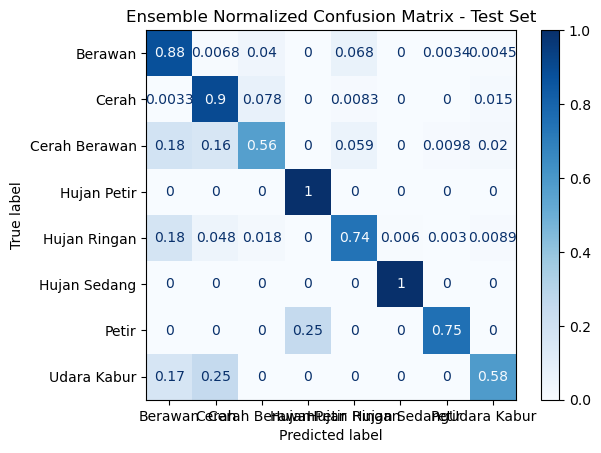


=== Confusion Matrix (Ensemble - Test Set) ===
               Berawan  Cerah  Cerah Berawan  Hujan Petir  Hujan Ringan  Hujan Sedang  Petir  Udara Kabur
Berawan            778      6             35            0            60             0      3            4
Cerah                2    541             47            0             5             0      0            9
Cerah Berawan       56     50            172            0            18             0      3            6
Hujan Petir          0      0              0            1             0             0      0            0
Hujan Ringan        59     16              6            0           249             2      1            3
Hujan Sedang         0      0              0            0             0             1      0            0
Petir                0      0              0            1             0             0      3            0
Udara Kabur          2      3              0            0             0             0      0            

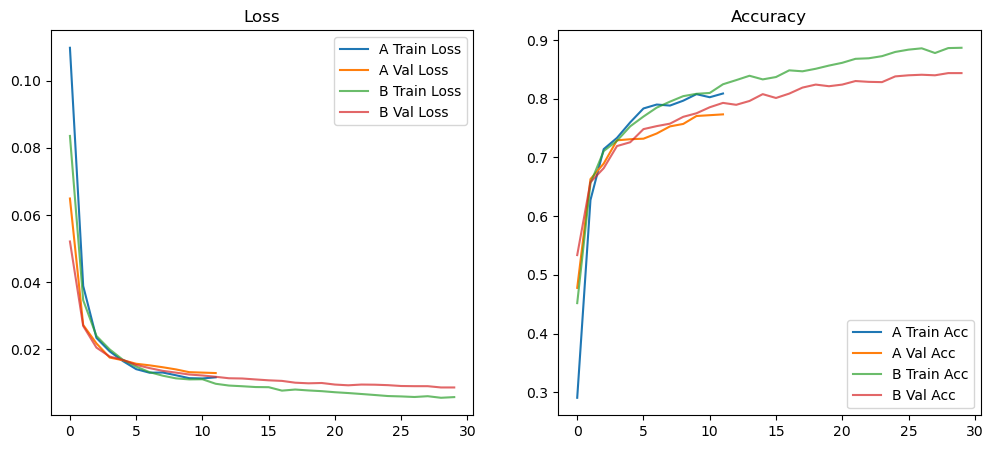

In [39]:
# =========================
# Evaluate on test
# =========================
test_probs_a = model_a.predict(X_test, verbose=0)
test_probs_b = model_b.predict(X_test, verbose=0)
test_probs_ens = (test_probs_a + test_probs_b) / 2.0
test_probs_ens = temperature_scale_probs(test_probs_ens, best_temp)

# apply per-class thresholds (with small bump)
y_pred_num = []
for p in test_probs_ens:
    adj = p.copy()
    applied = False
    for cls, th in best_thresholds.items():
        if adj[cls] >= th:
            adj[cls] += 1e-3
            applied = True
    if not applied:
        y_pred_num.append(np.argmax(p))
    else:
        y_pred_num.append(np.argmax(adj))
y_pred_num = np.array(y_pred_num)

# report
evaluate_preds(y_test, y_pred_num, le, title_prefix="Ensemble ")

# === Tambahan: Confusion Matrix (teks) ===
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

cm = confusion_matrix(y_test, y_pred_num, labels=range(len(le.classes_)))
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print("\n=== Confusion Matrix (Ensemble - Test Set) ===")
print(cm_df.to_string())

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm_df = pd.DataFrame(np.round(cm_norm, 3), index=le.classes_, columns=le.classes_)
print("\n=== Normalized Confusion Matrix (Ensemble - Test Set) ===")
print(cm_norm_df.to_string())

# print sample predictions
y_true_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(y_pred_num)
for i in range(min(10, len(y_test))):
    print(f"Sample {i+1}: Asli = {y_true_labels[i]}, Prediksi = {y_pred_labels[i]}")

# plot training histories (optional)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history_a.history.get('loss', []), label='A Train Loss')
plt.plot(history_a.history.get('val_loss', []), label='A Val Loss')
plt.plot(history_b.history.get('loss', []), label='B Train Loss', alpha=0.7)
plt.plot(history_b.history.get('val_loss', []), label='B Val Loss', alpha=0.7)
plt.legend(); plt.title("Loss")

plt.subplot(1,2,2)
plt.plot(history_a.history.get('accuracy', []), label='A Train Acc')
plt.plot(history_a.history.get('val_accuracy', []), label='A Val Acc')
plt.plot(history_b.history.get('accuracy', []), label='B Train Acc', alpha=0.7)
plt.plot(history_b.history.get('val_accuracy', []), label='B Val Acc', alpha=0.7)
plt.legend(); plt.title("Accuracy")
plt.show()


### Mapping Probabilitas ke 3 Kelas Utama

Fungsi `map_probs_to_3_classes(probs, classes)` digunakan untuk menggabungkan distribusi probabilitas dari model (8 kelas detail) menjadi 3 kategori utama:

- **Cerah** → gabungan dari `Cerah`, `Cerah Berawan`
- **Mendung** → gabungan dari `Berawan`, `Udara Kabur`
- **Hujan** → gabungan dari `Hujan Ringan`, `Hujan Sedang`, `Hujan Petir`, `Petir`

#### Alur Fungsi
1. Buat mapping `name_to_idx` untuk menghubungkan nama kelas → indeks.
2. Definisikan grup kelas (`groups`) sesuai kategori target.
3. Inisialisasi array kosong `mapped` dengan ukuran `(jumlah_sampel, 3)`.
4. Untuk setiap grup (`Cerah`, `Mendung`, `Hujan`):
   - Ambil indeks kelas detail yang termasuk dalam grup.
   - Jumlahkan probabilitas dari kelas-kelas tersebut.
   - Simpan hasilnya ke kolom yang sesuai di `mapped`.

#### Output
- Array 2D dengan bentuk `(n_samples, 3)` berisi probabilitas teragregasi:
  - Kolom 0 → probabilitas **Cerah**
  - Kolom 1 → probabilitas **Mendung**
  - Kolom 2 → probabilitas **Hujan**

---

In [33]:
def map_probs_to_3_classes(probs, classes):
    name_to_idx = {name: i for i, name in enumerate(classes)}
    groups = {
        "Cerah": ["Cerah", "Cerah Berawan"],
        "Mendung": ["Berawan", "Udara Kabur"],
        "Hujan": ["Hujan Ringan", "Hujan Sedang", "Hujan Petir", "Petir"],
    }
    mapped = np.zeros((probs.shape[0], 3), dtype=np.float32)
    for i, g in enumerate(["Cerah", "Mendung", "Hujan"]):
        idxs = [name_to_idx[n] for n in groups[g] if n in name_to_idx]
        if idxs:
            mapped[:, i] = probs[:, idxs].sum(axis=1)
    return mapped


### Membuat dan Menyimpan Model Ensemble

Setelah melatih **Model A (BiLSTM)** dan **Model B (TCN)**, kita dapat membungkus keduanya menjadi satu model ensemble agar lebih praktis digunakan saat inference maupun deployment.

#### Kode & Penjelasan
```python
from tensorflow.keras.layers import Average
from tensorflow.keras.models import Model

# Bungkus ensemble jadi satu model
avg_output = Average()([model_a.output, model_b.output])  
# → Mengambil output softmax dari model_a & model_b, lalu menghitung rata-rata probabilitasnya

ensemble_model = Model(inputs=[model_a.input, model_b.input], outputs=avg_output)  
# → Membuat model baru dengan input sama seperti model_a & model_b, output = avg_output

# Simpan
ensemble_model.save("Hasil_Forecasting/ensamble_model.h5")  
# → Menyimpan model ensemble ke file .h5 agar bisa dipakai kembali


In [43]:
from tensorflow.keras.layers import Average
from tensorflow.keras.models import Model

avg_output = Average()([model_a.output, model_b.output])
ensemble_model = Model(inputs=[model_a.input, model_b.input], outputs=avg_output)

ensemble_model.save(r"../Result Model/forecasting_model.h5") 

### Menyimpan Parameter Normalisasi dan Label Kelas

Menyimpan dua file penting untuk keperluan inference:

- `scaler.json` → berisi parameter normalisasi (`mean` dan `std`) dari data training.
- `labels.json` → berisi mapping indeks ke nama kelas cuaca.

In [ ]:
scaler_data = {
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist()
}

with open("Hasil_Forecasting/scaler.json", "w") as f:
    json.dump(scaler_data, f)

print("scaler.json berhasil dibuat")


labels_data = {i: label for i, label in enumerate(le.classes_)}

with open("Hasil_Forecasting/labels.json", "w") as f:
    json.dump(labels_data, f, ensure_ascii=False)

print("labels.json berhasil dibuat")


scaler.json berhasil dibuat
labels.json berhasil dibuat
